# GNATFinder Tutorial
### Brad Theilman 2025-06
SAND2025-07229C

We first generate spiking data from an 80/20 spiking neural network model. 
Then we use GNATFinder to extract Graphical Neural Activity Threads from the dataset and compute (quasi)-isomorphic subthreads corresponding to putative computations.

In [1]:
# Import libraries
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import yaml
import subprocess
import networkx as nx
import matplotlib.colors as mcolors

## Global parameters
These settings set paths to executables and intermediate files and define constants that are used throughout the analysis

In [2]:
# Network and Simulation Parameters
sim_plastic_T = 10 * 60 * 1000 # plastic simulation time in milliseconds (default = 10 minutes)
sim_static_T = 180 * 1000  # static simulation time in milliseconds (default = 3 minutes)

sim_plastic_randseed = 83091
sim_static_randseed  = 6502

n_neurons = 1000

# GNATFinder parameters
analysis_tmin = 60000
analysis_tmax = 120000

# GNAT timescale parameters
tau    = 5
thresh = 4
radius = 100

# paths to preprocessed files
gnat_acty_file       = './gnat_acty.txt'
gnat_shuff_acty_file = './gnat_acty_shuff.txt'

gnat_adjcy_file      = './gnat_adjcy.txt'
gnat1_out_file       = './gnat1_out.txt'
gnat1_cdh_file       = './gnat1_cdh.txt'
gnat1_shuff_cdh_file = './gnat1_cdh_shuff.txt'
gnat2_out_file       = './gnat2_out.txt'

# Paths to programs
stacsdir   = '/home/bhtheil/code/stacs_github/'
gnat1_path = '/home/bhtheil/code/gnatfinder/gnat1'
gnat2_path = '/home/bhtheil/code/gnatfinder/gnatfinder'

## Build and simulate an 80/20 spiking network 
First we build and simulate an 80/20 spiking network with spike-timing plasticity for 10 simulated minutes. 
This generates a network with sparse, balanced spiking activity resembling cortical activity in vivo.
The model is essentially equivalent to Izhikevich (2005)

In [3]:
charmrun = os.path.join(stacsdir, 'charmrun')
charm_pe = '+p8'
stacsbin = os.path.join(stacsdir, 'stacs')
netwkdir = os.path.join(stacsdir, 'sims/polynet')
netconf = os.path.join(netwkdir, 'polynet.yml')
runmode = 'buildsim'

with open(netconf,"r") as file:
    simconfig = yaml.safe_load(file)
    
simconfig['netwkdir'] = netwkdir
simconfig['runmode'] = 'buildsim'
simconfig['plastic'] = True
simconfig['tmax'] = sim_plastic_T
simconfig['randseed'] = sim_plastic_randseed

with open(netconf, "w") as file:
    yaml.dump(simconfig, file)

# Command to run (as list)
runcmd = charmrun + ' ' + charm_pe + ' ' + stacsbin + ' ' + netconf + ' ' + runmode
print(runcmd)

# Use subprocess to run
subprocess.run(runcmd.split(), cwd=stacsdir)

/home/bhtheil/code/stacs_github/charmrun +p8 /home/bhtheil/code/stacs_github/stacs /home/bhtheil/code/stacs_github/sims/polynet/polynet.yml buildsim

Running as 8 OS processes: /home/bhtheil/code/stacs_github/stacs /home/bhtheil/code/stacs_github/sims/polynet/polynet.yml buildsim
charmrun> /usr/bin/setarch x86_64 -R mpirun -np 8 /home/bhtheil/code/stacs_github/stacs /home/bhtheil/code/stacs_github/sims/polynet/polynet.yml buildsim
Charm++> Running on MPI library: MPICH Version:	3.3.2
MPICH Release date:	Tue Nov 12 21:23:16 CST 2019
MPICH ABI:	13:8:1
MPICH Device:	ch3:nemesis
MPICH configure:	--build=x86_64-linux-gnu --prefix=/usr --includedir=${prefix}/include --mandir=${prefix}/share/man --infodir=${prefix}/share/info --sysconfdir=/etc --localstatedir=/var --disable-silent-rules --libdir=${prefix}/lib/x86_64-linux-gnu --runstatedir=/run --disable-maintainer-mode --disable-dependency-tracking --with-libfabric --enable-shared --prefix=/usr --enable-fortran=all --disable-rpath --disable-

CompletedProcess(args=['/home/bhtheil/code/stacs_github/charmrun', '+p8', '/home/bhtheil/code/stacs_github/stacs', '/home/bhtheil/code/stacs_github/sims/polynet/polynet.yml', 'buildsim'], returncode=0)

The next cell moves some files so that the final network configuration under synaptic plasticity becomes the initial network with fixed connectivity and weights

In [4]:
# move files
!for i in $( ls ./polynet/polynet.out.* ); do j="$(echo ${i} |sed -e 's/.out//')"; mv "${i}" "${j}"; done

### Simulate a frozen, equilibrated spiking network
Next, we freeze the weights and simulate for 3 minutes to generate spiking activity we'll analyze with GNATFinder

In [5]:
with open(netconf,"r") as file:
    simconfig = yaml.safe_load(file)
    
simconfig['runmode'] = 'simulate'
simconfig['plastic'] = False
simconfig['tmax'] = sim_static_T
simconfig['randseed'] = sim_static_randseed
with open(netconf, "w") as file:
    yaml.dump(simconfig, file)

# Command to run (as list)
runcmd = charmrun + ' ' + charm_pe + ' ' + stacsbin + ' ' + netconf
print(runcmd)

# Use subprocess to run
subprocess.run(runcmd.split(), cwd=stacsdir)

/home/bhtheil/code/stacs_github/charmrun +p8 /home/bhtheil/code/stacs_github/stacs /home/bhtheil/code/stacs_github/sims/polynet/polynet.yml

Running as 8 OS processes: /home/bhtheil/code/stacs_github/stacs /home/bhtheil/code/stacs_github/sims/polynet/polynet.yml
charmrun> /usr/bin/setarch x86_64 -R mpirun -np 8 /home/bhtheil/code/stacs_github/stacs /home/bhtheil/code/stacs_github/sims/polynet/polynet.yml
Charm++> Running on MPI library: MPICH Version:	3.3.2
MPICH Release date:	Tue Nov 12 21:23:16 CST 2019
MPICH ABI:	13:8:1
MPICH Device:	ch3:nemesis
MPICH configure:	--build=x86_64-linux-gnu --prefix=/usr --includedir=${prefix}/include --mandir=${prefix}/share/man --infodir=${prefix}/share/info --sysconfdir=/etc --localstatedir=/var --disable-silent-rules --libdir=${prefix}/lib/x86_64-linux-gnu --runstatedir=/run --disable-maintainer-mode --disable-dependency-tracking --with-libfabric --enable-shared --prefix=/usr --enable-fortran=all --disable-rpath --disable-wrapper-rpath --sysconfdir=

CompletedProcess(args=['/home/bhtheil/code/stacs_github/charmrun', '+p8', '/home/bhtheil/code/stacs_github/stacs', '/home/bhtheil/code/stacs_github/sims/polynet/polynet.yml'], returncode=0)

## Preprocess STACS output for the GNATFinder analysis

Next, extract the spikes and connectivity from the STACS simulation and build input files for GNATFinder

In [6]:
# Network simulation yaml
stacsdir = '/home/bhtheil/code/stacs_github'
netwkdir = os.path.join(stacsdir, 'sims/polynet/')
configfile = os.path.join(netwkdir, 'polynet.yml')
with open(configfile,"r") as file:
    simconfig = yaml.safe_load(file)
    
recordir = netwkdir + '/' + simconfig['recordir']
print("Network directory: {}".format(netwkdir))

# Snapshot information
filebase = simconfig['filebase']
netfiles = int(simconfig['netfiles'])
netparts = int(simconfig['netparts'])
print("Network filebase: {}".format(filebase))
print("Number of files: {}".format(netfiles))
print("Number of parts: {}".format(netparts))

# Timing information
tmax = float(simconfig['tmax'])
tstep = float(simconfig['tstep'])
trecord = float(simconfig['trecord'])
print("Max simulation time: {}".format(tmax))
print("Simulation timestep: {}".format(tstep))
print("Recording interval: {}".format(trecord))

# Graph information (number of vertices)
graphfile = os.path.join(stacsdir, netwkdir, '{}.graph'.format(filebase))
print(graphfile)
with open(graphfile,"r") as file:
    graphconfig = yaml.safe_load(file)

# Vertex population sizes
vertex_modname = []
vertex_order = []
for vertex in graphconfig['vertex']:
    vertex_modname.append(vertex['modname'])
    vertex_order.append(vertex['order'])
    print("Vertex model {} : {}".format(vertex['modname'], vertex['order']))
vertex_prefix = [0] + [sum(vertex_order[:i+1]) for i in range(len(vertex_order))]
print("Prefix sum: {}".format(vertex_prefix))

print(vertex_modname)

# Because the neuron models are distributed over multiple partitions,
# we need to find the reindexing mapping for cleaner plotting
vertex_remap = np.zeros(vertex_prefix[-1]).astype(int)

# global and per-population counters
vertex_global_index = 0
vertex_model_index = np.zeros(len(vertex_modname)).astype(int)

# Loop through the state files
for fileidx in range(netfiles):
    # fname = stacsdir + '/' + netwkdir + '/' + filebase + '.state.' + str(fileidx)
    fname = os.path.join(stacsdir, netwkdir, '{}.state.{}'.format(filebase, fileidx))
    with open(fname, 'r') as fstate:
        for line_num, line in enumerate(fstate):
            # the vertex model name is the first word per line
            modname = line.split(None, 1)[0]

            # the vertex_remap takes a STACS global index and maps it to a new global index organized by population
            # the population boundaries are carried by vertex_prefix
            vertex_remap[vertex_global_index] = vertex_prefix[vertex_modname.index(modname)] \
                                              + vertex_model_index[vertex_modname.index(modname)]
            vertex_global_index += 1
            vertex_model_index[vertex_modname.index(modname)] += 1

Network directory: /home/bhtheil/code/stacs_github/sims/polynet/
Network filebase: polynet
Number of files: 4
Number of parts: 8
Max simulation time: 180000.0
Simulation timestep: 1.0
Recording interval: 60000.0
/home/bhtheil/code/stacs_github/sims/polynet/polynet.graph
Vertex model izhiex : 800
Vertex model izhiin : 200
Vertex model izhithal : 1
Prefix sum: [0, 800, 1000, 1001]
['izhiex', 'izhiin', 'izhithal']


In [7]:
# Reading in data from event logs, which are stored 
# by recording interval in simulation iterations
record_interval = int(trecord/tstep)
record_max = int(tmax/tstep)
record_points = list(range(record_interval, record_max, record_interval))+[record_max]
print("Recording points: {}".format(record_points))

# Conversion from timestamp 'tick' to milliseconds
TICKS_PER_MS = 1000000

f = open(gnat_acty_file, 'w')
fshuff = open(gnat_shuff_acty_file, 'w')

trange = record_points
trange = [analysis_tmax]

tmin = analysis_tmin
tmax = analysis_tmax

# Collect spikes into an event list
event_list = [[] for _ in range(vertex_prefix[-1])]
event_count = 0
for record in trange:
    for fileidx in range(netfiles):
        # fname = stacsdir + '/' + recordir + '/' + filebase + '.evtlog.' + str(record) + '.' + str(fileidx)
        fname = os.path.join(stacsdir, recordir, '{}.evtlog.{}.{}'.format(filebase, record, fileidx))
        with open(fname, 'r') as file:
            for line in file:
                # the event format is [event type, timestamp, vertex index, optional payload]
                event = line.split()
                event_type = int(event[0])
                timestamp = int(event[1], 16) // TICKS_PER_MS  #INTEGER timestamp

                shuff_timestamp = np.random.randint(tmin, tmax)
                global_index = int(event[2])
                # reindex the events
                index = int(vertex_remap[global_index])
            
                # spikes are event type "0"
                if event_type == 0:
                    event_list[index].append(timestamp)
                    event_count += 1
                    if index < 800:
                        gf_line = '0 {} {}\n'.format(hex(timestamp)[2:], index)
                        gf_shuff_line = '0 {} {}\n'.format(hex(shuff_timestamp)[2:], index)
                        f.write(gf_line)
                        fshuff.write(gf_shuff_line)


print("Total events: {}".format(event_count))
f.close()
fshuff.close()

Recording points: [60000, 120000, 180000]
Total events: 277014


In [8]:
# this is the index of the desired state (in this case synaptic weight)
state_modname = 'exstdp'
state_index = 1 
delay_index = 5

edge_modnames = ['none', 'exstdp', 'instdp', 'thampl']

vtx_pos_2D = []

## Adjcy information (edge lists)
post_vtx_global_idx = 0
f = open(gnat_adjcy_file, 'w')
for datidx in range(0,netfiles) :
    fname = netwkdir + '/' + filebase + '.adjcy.' + str(datidx)
    fname2 = netwkdir + '/' + filebase + '.state.' + str(datidx)
    fname3 = netwkdir + '/' + filebase + '.coord.' + str(datidx)
    with open(fname,'r') as fadjcy, open(fname2,'r') as fstate, open(fname3, 'r') as fcoord:
        # Line by line
        for l, (ladjcy, lstate, lcoord) in enumerate(zip(fadjcy, fstate, fcoord)):
            lcoord_split = lcoord.split()
            vtx_pos_2D.append(np.array([float(x) for x in lcoord_split]))
            # list comprehension to extract a list of edge models for a given vertex
            lstate_split = lstate.split() # cache this
            edge_models = [model for model in lstate_split if any(modname in model for modname in edge_modnames)]
            edge_idxs = [i for i, model in enumerate(lstate_split) if any(modname in model for modname in edge_modnames)]
            
            # get rms excitatory weight
            w_rms = np.sqrt(np.sum([float(lstate_split[edge_idxs[w]+state_index])**2 for w, _ in enumerate(ladjcy.split()) if edge_models[w] == state_modname]))
            # print(w_rms)
            # edge by edge
            for w, wadjcy in enumerate(ladjcy.split()):
                if edge_models[w] != 'none':
                    if edge_models[w] == state_modname:
                        wgt = float(lstate_split[edge_idxs[w]+state_index])
                        relative_wgt = wgt / w_rms
                        delay = int(lstate_split[edge_idxs[w]+delay_index],16)//TICKS_PER_MS
                        pre_idx = int(vertex_remap[int(wadjcy)])
                        post_idx = int(vertex_remap[post_vtx_global_idx])  
                        # print(pre_idx, post_idx, wgt, delay)
                        if post_idx < 800:
                            fline = '{} {} {} {}\n'.format(pre_idx, post_idx, relative_wgt, delay)
                            f.write(fline)
            post_vtx_global_idx += 1

f.close()

### Plot the spike raster
We will analyze these spikes with GNATFinder.  Much like cortical activity the spikes are mostly asynchronous and fixed-rate

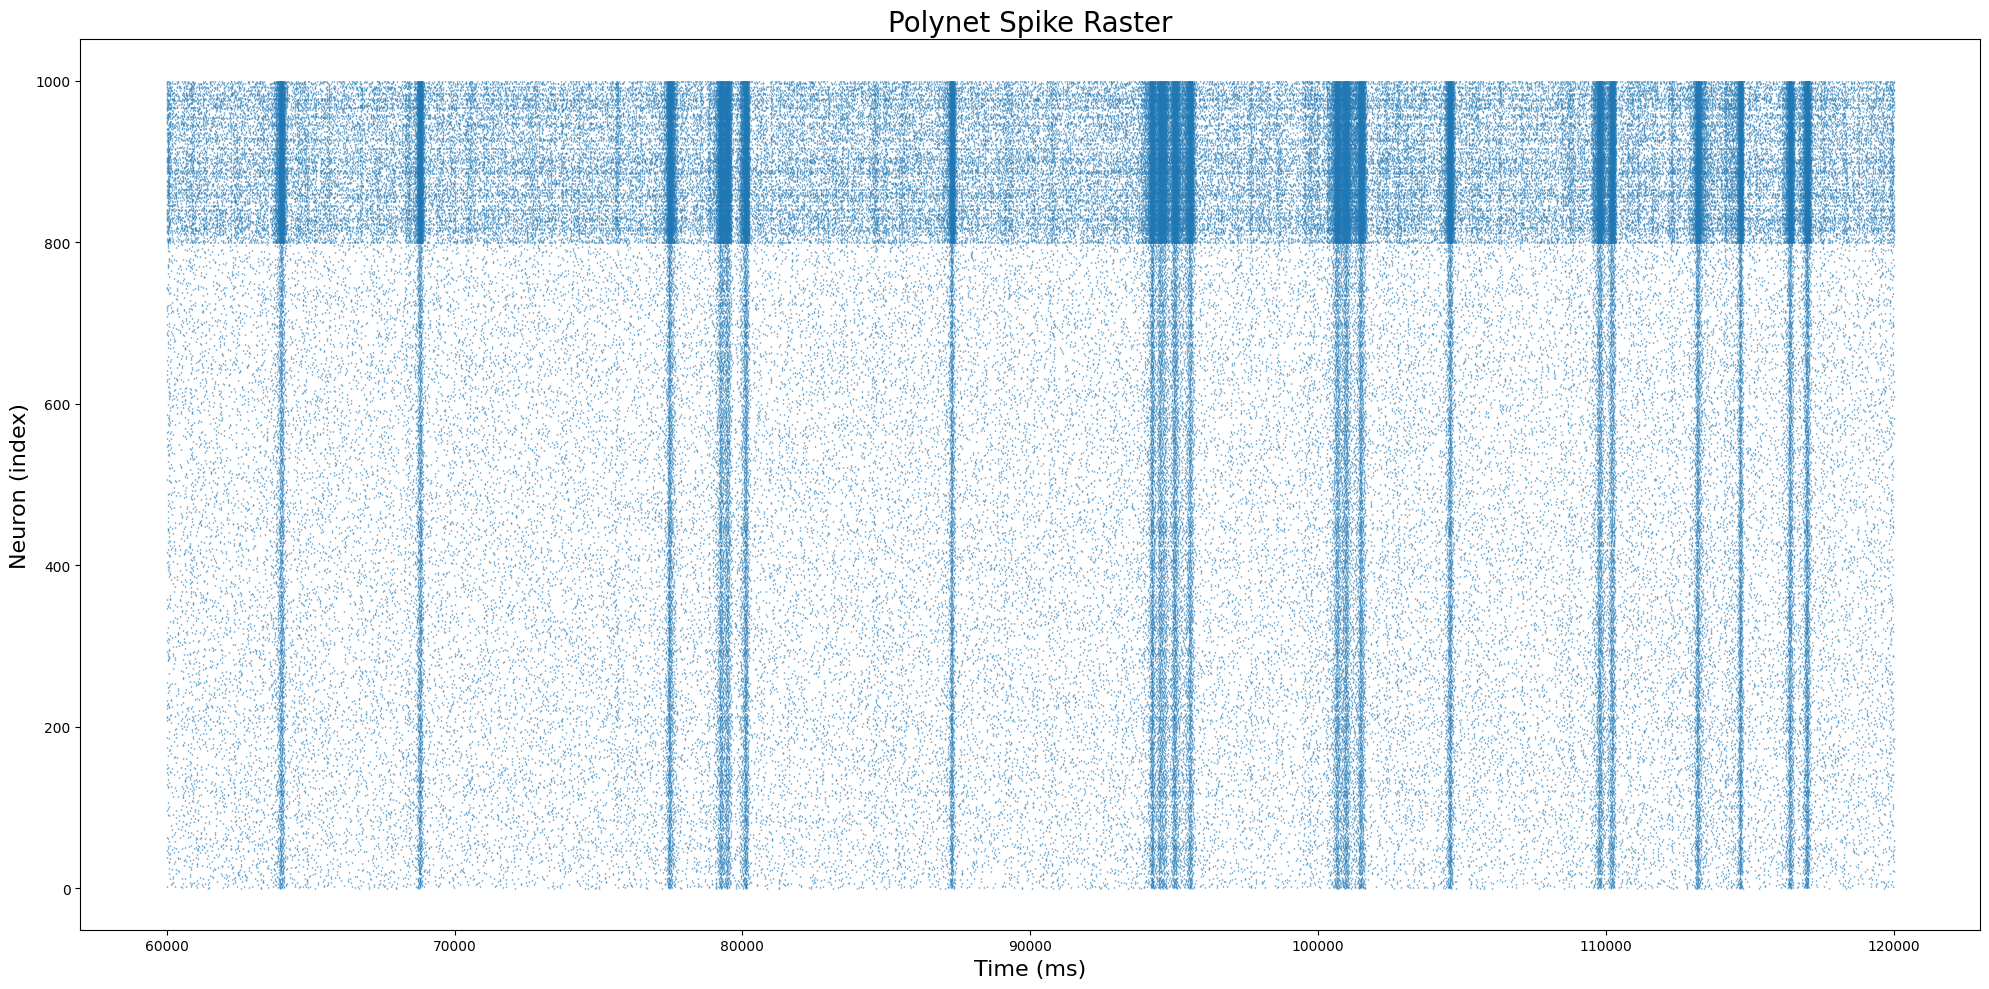

In [9]:
## Plot the event data
fig, axs = plt.subplots(1,1,figsize=(20,10))
axs.eventplot(event_list,lineoffsets=1,linelengths=1,linewidths=1)
plt.title('Polynet Spike Raster', fontsize=20)
plt.xlabel('Time (ms)', fontsize=16)
plt.ylabel('Neuron (index)', fontsize=16)
plt.tight_layout()
# plt.xlim([60000, 120000])

## Run GNATFinder to find first order gnats

These cells use GNATFinder to identify causally significant synaptic interactions in the spiking data (with respect to the Omega quantity)
The identified GNATs are visualized by coloring individual spikes according to their parent GNAT.  Edges are not drawn for clarity.

In [10]:
gnat1_cmd = gnat1_path + ' ' + '{}'.format(n_neurons) + ' ' + gnat_adjcy_file + ' ' + gnat_acty_file + ' 1 ' + gnat1_out_file + ' {} {} {}'.format(tau, thresh, radius)
gnat1_cdh_cmd = gnat1_path + ' ' + '{}'.format(n_neurons) + ' ' + gnat_adjcy_file + ' ' + gnat_acty_file + ' 2 ' + gnat1_cdh_file + ' {} {} {}'.format(tau, thresh, radius)
gnat1_cdh_shuff_cmd = gnat1_path + ' ' + '{}'.format(n_neurons) + ' ' + gnat_adjcy_file + ' ' + gnat_shuff_acty_file + ' 2 ' + gnat1_shuff_cdh_file + ' {} {} {}'.format(tau, thresh, radius)

print(gnat1_cmd)

# Use subprocess to run
subprocess.run(gnat1_cmd.split(), cwd='./')
subprocess.run(gnat1_cdh_cmd.split(), cwd='./')
subprocess.run(gnat1_cdh_shuff_cmd.split(), cwd='./')

/home/bhtheil/code/gnatfinder/gnat1 1000 ./gnat_adjcy.txt ./gnat_acty.txt 1 ./gnat1_out.txt 5 4 100
Reading event file...
Opened file: ./gnat_acty.txt
Reading connectivity file...
Opened connectivity file: ./gnat_adjcy.txt
Computing activity threads...
Done
Reading event file...
Opened file: ./gnat_acty.txt
Reading connectivity file...
Opened connectivity file: ./gnat_adjcy.txt
Computing activity threads...
Done
Reading event file...
Opened file: ./gnat_acty_shuff.txt
Reading connectivity file...
Opened connectivity file: ./gnat_adjcy.txt
Computing activity threads...
Done


CompletedProcess(args=['/home/bhtheil/code/gnatfinder/gnat1', '1000', './gnat_adjcy.txt', './gnat_acty_shuff.txt', '2', './gnat1_cdh_shuff.txt', '5', '4', '100'], returncode=0)

In [11]:
nodes = []
with open(gnat_acty_file, 'r') as f:
    for l in f:
        line_split = l.split()
        if int(line_split[0]) == 0:
            nodes.append((int(line_split[2]), int(line_split[1], 16)))

# convert to event lists
all_spikes_cells = np.array([x[0] for x in nodes], dtype=np.int64)
all_spikes_times = np.array([x[1] for x in nodes], dtype=np.int64)
            
edges = []
with open(gnat1_out_file, 'r') as f:
    for l in f:
        line = [int(x) for x in l.split()]
        edges.append(((line[0], line[1]), (line[2], line[3])))

G_gnat1 = nx.DiGraph()
G_gnat1.add_nodes_from(nodes)
G_gnat1.add_edges_from(edges)

print(G_gnat1)

DiGraph with 115840 nodes and 504308 edges


### Plot Causal Distance Histogram

This cell shows the distribution of -log Omega values from the dataset.  It is useful for validating analysis parameters.  Smaller values in this plot indicate stronger causal influence.

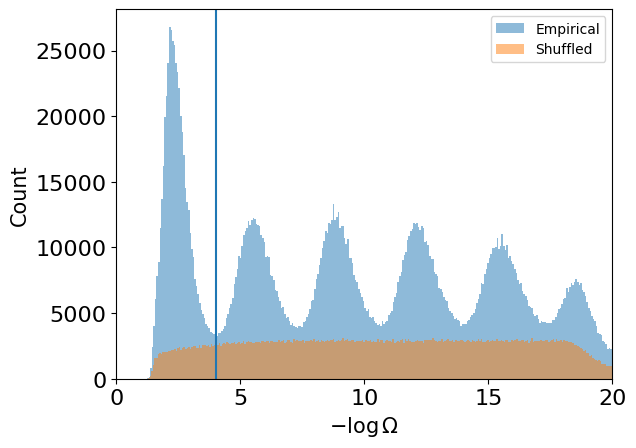

In [20]:
fig, ax = plt.subplots(1,1)
cdh = []
cdh_shuff = []
with open(gnat1_cdh_file, 'r') as f:
    for line in f:
        # print(line)
        if line != 'inf\n':
            cdh.append(float(line))

with open(gnat1_shuff_cdh_file, 'r') as f:
    for line in f:
        # print(line)
        if line != 'inf\n':
            cdh_shuff.append(float(line))
            
_=ax.hist(cdh, bins=500, alpha=0.5, label='Empirical')
_=ax.hist(cdh_shuff, bins=500, alpha=0.5, label='Shuffled')
ax.set_xlim(0, 20)
ax.axvline(thresh, 0, 1)

ax.set_xlabel('$- \log \Omega$', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.tick_params('both', labelsize=16)
ax.legend()

### Plot GNATs

These next two cells plot rasters labeled by GNAT (color).  The first gives a single plot of the whole analysis window, while the second expands the plot to see more detail

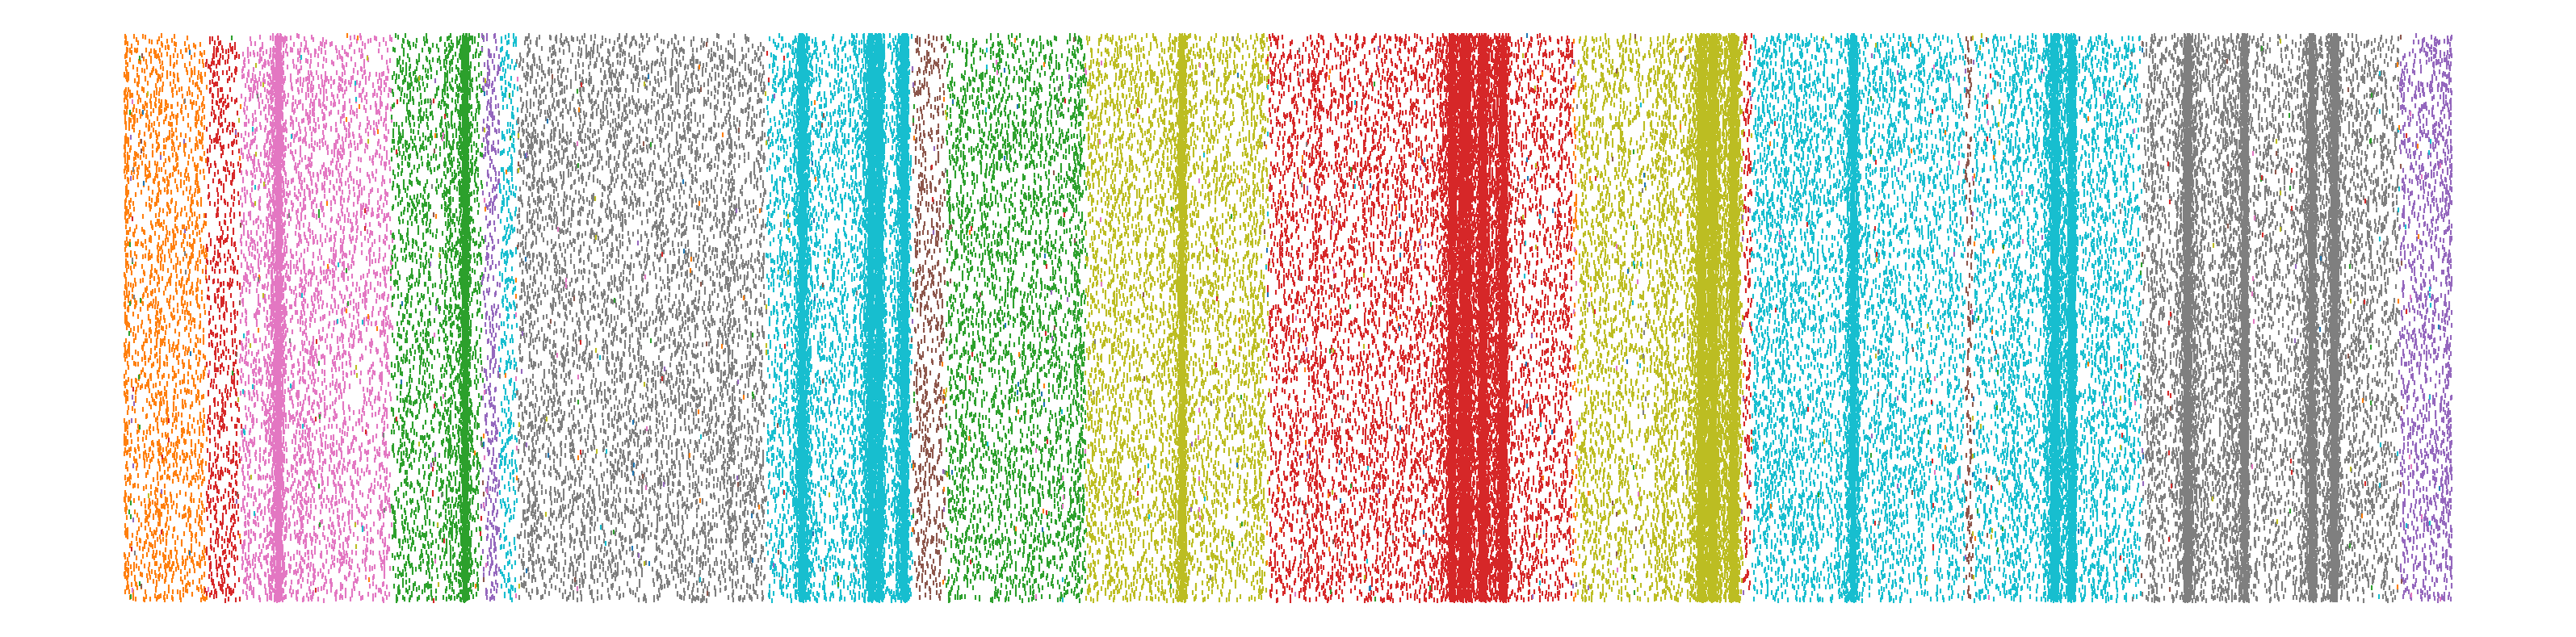

In [13]:
# Plot the isomorphic causal subgraphs
def get_pos(G):
    pos = {}
    for s in G.nodes():
        pos[s] = (s[1]/1000,s[0]/10)
    return pos
        
def get_center(pos):
    return np.mean([x[0] for x in pos.values()])

gnats = list(nx.weakly_connected_components(G_gnat1))
gnat_colors = list(mcolors.TABLEAU_COLORS)

fig, ax = plt.subplots(1,1, figsize=(32, 8), tight_layout=True)
for gidx, g in enumerate(gnats):
    if len(g) < 2:
        continue
        
    gnat = G_gnat1.subgraph(g)
    pos = get_pos(gnat)
    center = get_center(pos)
    c = gnat_colors[gidx % len(gnat_colors)]
    nx.draw_networkx(gnat, pos, node_size=16, ax = ax, with_labels=False, arrows=True, alpha=1, node_color = c, 
                     width=0.25, edge_vmin=0, edge_vmax=0.75, node_shape="|", edge_color='gray', edgelist=[])

ax.set_frame_on(False)

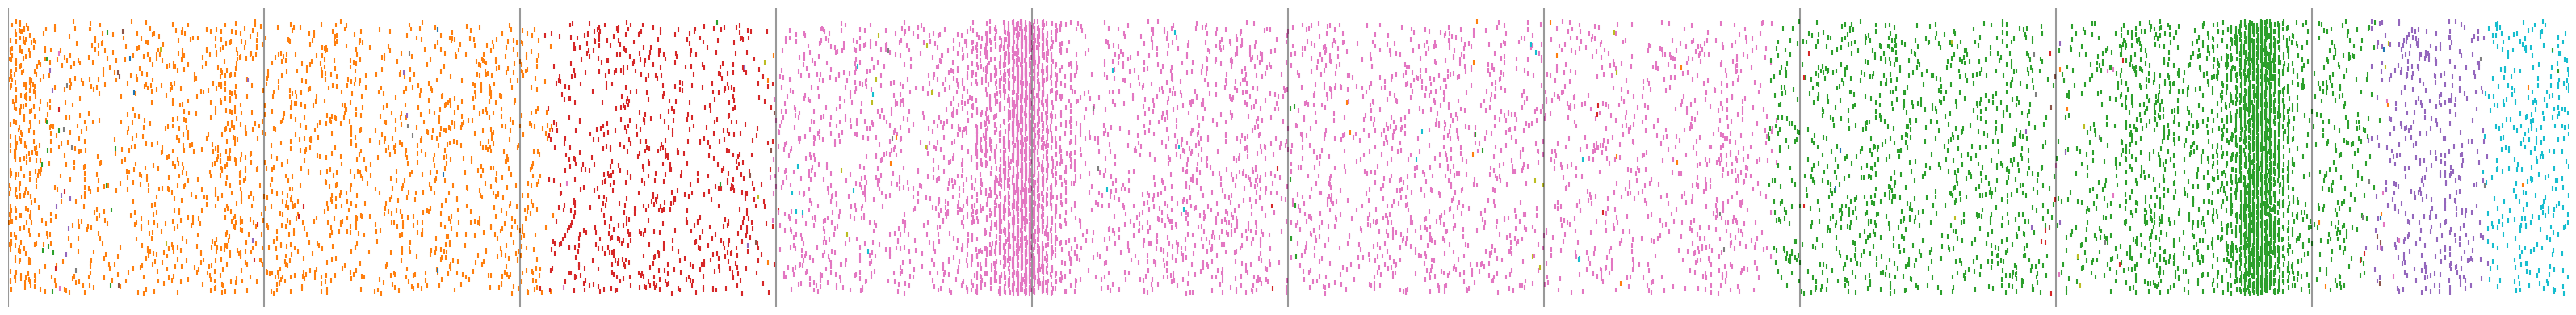

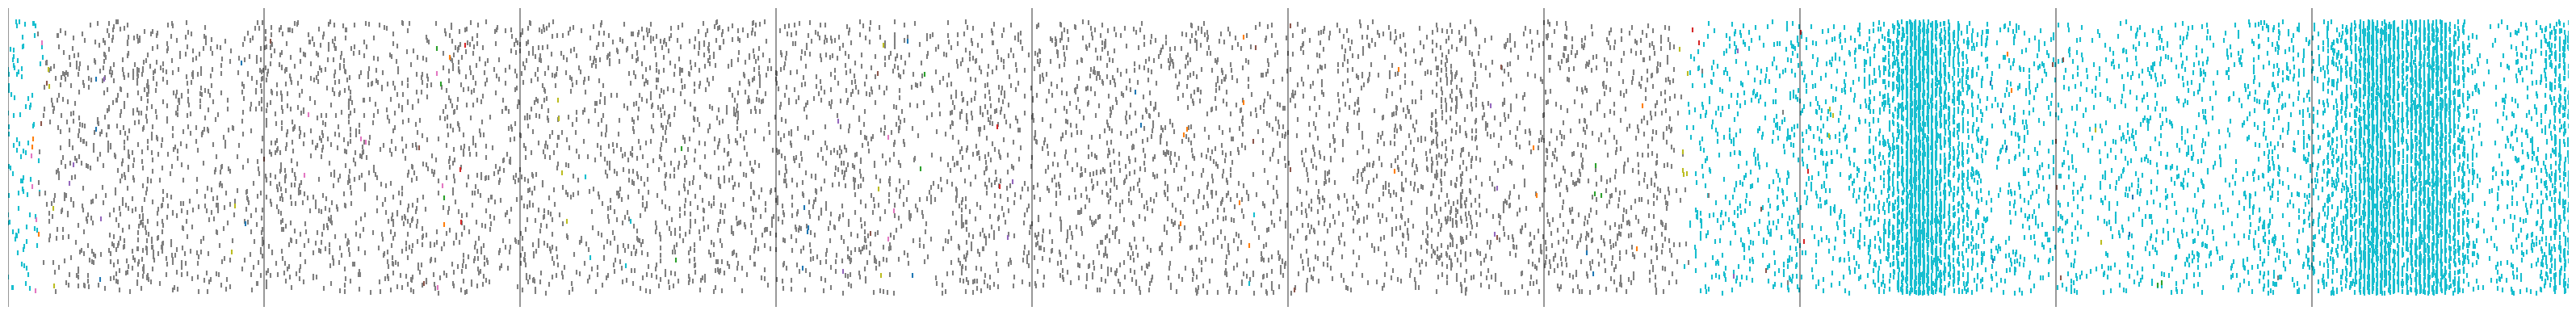

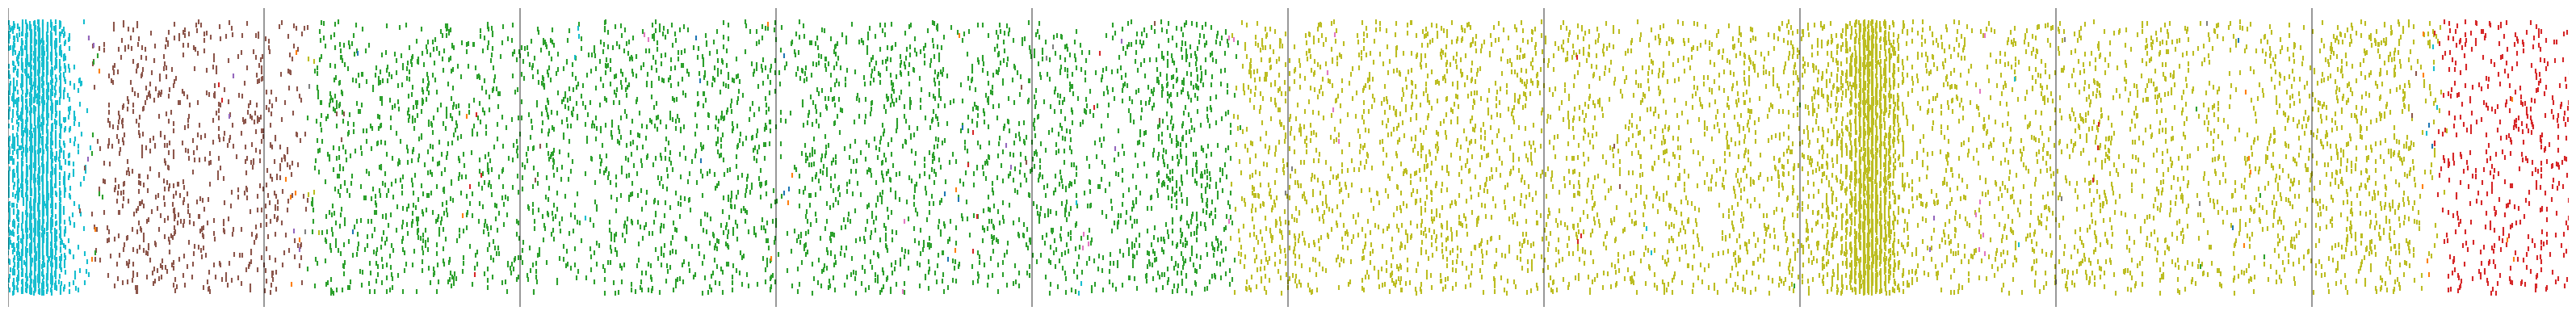

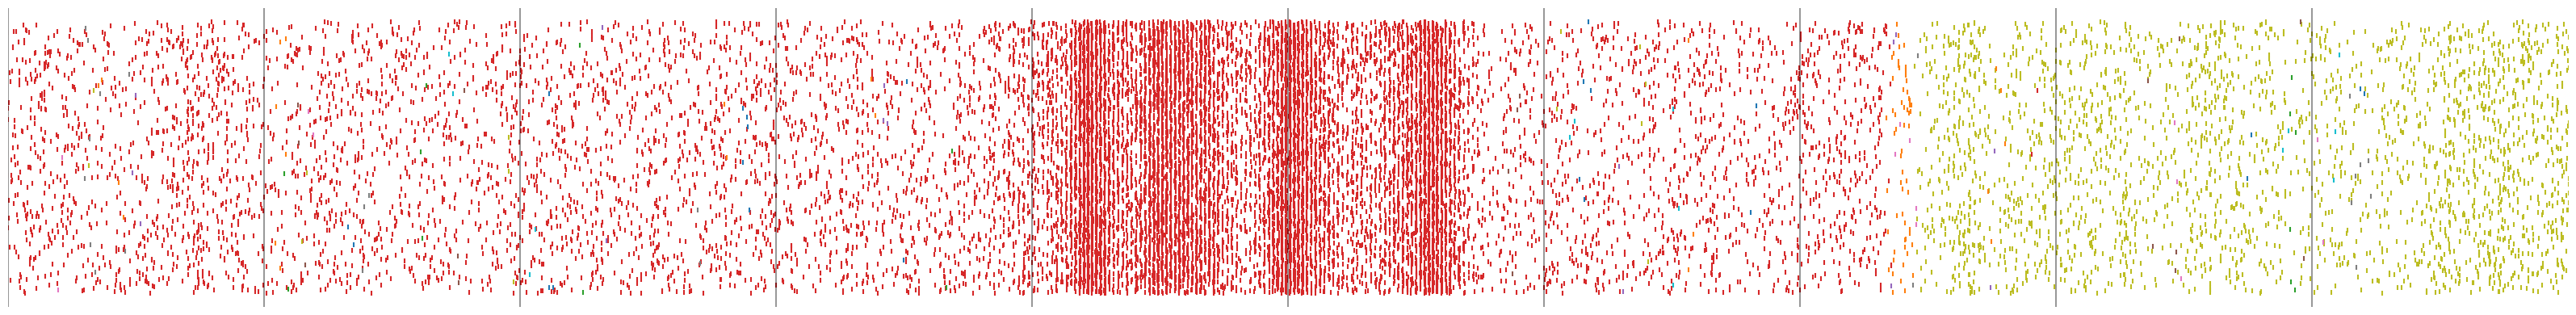

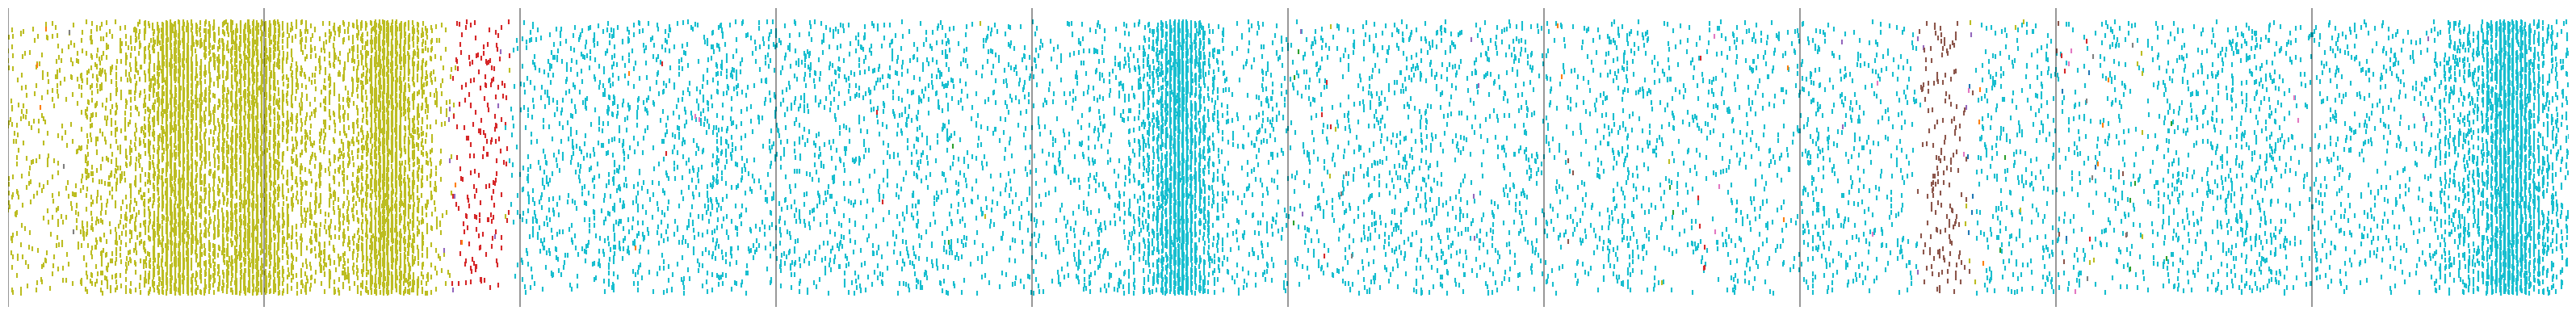

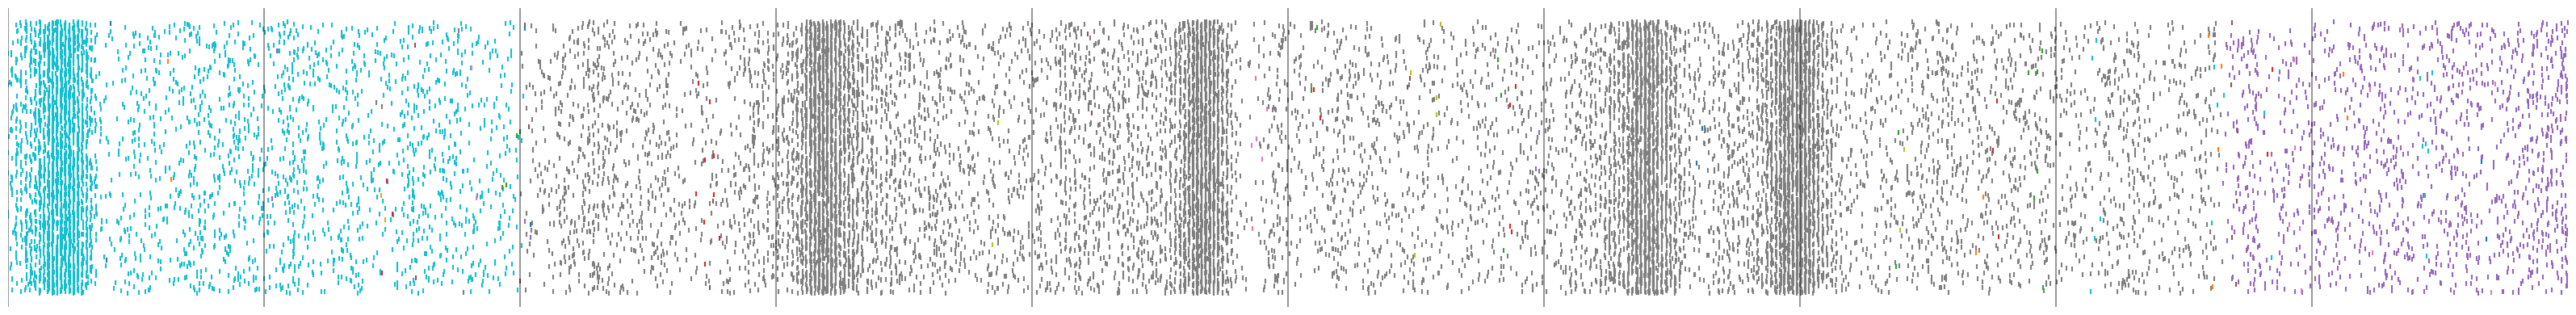

In [14]:
# Plot the isomorphic causal subgraphs
for i in range(6):
    fig, ax = plt.subplots(1,1, figsize=(32, 4), tight_layout=True)

    tstart = 60 + 10*i
    tend   = 70 + 10*i
    for gidx, g in enumerate(gnats):
        if len(g) < 2:
            continue
            
        gnat = G_gnat1.subgraph(g)
        pos = get_pos(gnat)
        center = get_center(pos)
        c = gnat_colors[gidx % len(gnat_colors)]
        nx.draw_networkx(gnat, pos, node_size=16, ax = ax, with_labels=False, arrows=True, alpha=1, node_color = c, 
                         width=0.25, edge_vmin=0, edge_vmax=0.75, node_shape="|", edge_color='gray', edgelist=[])
    
    ax.set_frame_on(False)
    ax.set_xlim([tstart, tend])
    for j in range(tstart, tend, 1):
        ax.axvline(j, 0, 1, alpha=0.4, color='k')

## Find Quasi-isomorphic subthreads with GNATFinder

Here we run the second-order gnatfinder to identify putative (quasi-)isomorphisms between subgraphs of the extracted GNATs.
This may take several minutes.  At the end, an arbitrary example is plotted

In [15]:
# run gnatfinder to extract isomorphic subthreads

gnat2_cmd = gnat2_path + ' ' + '{}'.format(n_neurons) + ' ' + gnat_acty_file + ' ' + gnat_adjcy_file + ' {} {} {}'.format(tau, thresh, radius)

print(gnat2_cmd)

# Use subprocess to run
subprocess.run(gnat2_cmd.split(), cwd='./')

/home/bhtheil/code/gnatfinder/gnatfinder 1000 ./gnat_acty.txt ./gnat_adjcy.txt 5 4 100
Cell 0 of 1000
Cell 10 of 1000
Cell 20 of 1000
Cell 30 of 1000
Cell 40 of 1000
Cell 50 of 1000
Cell 60 of 1000
Cell 70 of 1000
Cell 80 of 1000
Cell 90 of 1000
Cell 100 of 1000
Cell 110 of 1000
Cell 120 of 1000
Cell 130 of 1000
Cell 140 of 1000
Cell 150 of 1000
Cell 160 of 1000
Cell 170 of 1000
Cell 180 of 1000
Cell 190 of 1000
Cell 200 of 1000
Cell 210 of 1000
Cell 220 of 1000
Cell 230 of 1000
Cell 240 of 1000
Cell 250 of 1000
Cell 260 of 1000
Cell 270 of 1000
Cell 280 of 1000
Cell 290 of 1000
Cell 300 of 1000
Cell 310 of 1000
Cell 320 of 1000
Cell 330 of 1000
Cell 340 of 1000
Cell 350 of 1000
Cell 360 of 1000
Cell 370 of 1000
Cell 380 of 1000
Cell 390 of 1000
Cell 400 of 1000
Cell 410 of 1000
Cell 420 of 1000
Cell 430 of 1000
Cell 440 of 1000
Cell 450 of 1000
Cell 460 of 1000
Cell 470 of 1000
Cell 480 of 1000
Cell 490 of 1000
Cell 500 of 1000
Cell 510 of 1000
Cell 520 of 1000
Cell 530 of 1000
Cell 5

CompletedProcess(args=['/home/bhtheil/code/gnatfinder/gnatfinder', '1000', './gnat_acty.txt', './gnat_adjcy.txt', '5', '4', '100'], returncode=0)

In [16]:
edges = []
with open(gnat2_out_file, 'r') as f:
    for l in f:
        line = [int(x) for x in l.split()]
        spp1 = ((line[0], line[1]), (line[0], line[2]))
        spp2 = ((line[3], line[4]), (line[3], line[5]))
        edges.append((spp1, spp2))

G_gnat2 = nx.DiGraph()
G_gnat2.add_edges_from(edges)

In [17]:
# get wccs
gnat2_isos = list(sorted(nx.weakly_connected_components(G_gnat2), key=len, reverse=True))
gnat1_gnats = list(sorted(nx.weakly_connected_components(G_gnat1), key=len, reverse=True))

print(len(gnat2_isos))

778372


In [18]:
# extract the subgraphs of the first order activity graph corresponding to the repeat patterns
idx=5101 

sps_1 = [x[0] for x in gnat2_isos[idx]]
sps_2 = [x[1] for x in gnat2_isos[idx]]

cq1_g1 = G_gnat1.subgraph(sps_1)
cq1_g2 = G_gnat1.subgraph(sps_2)
print(cq1_g1)
print(cq1_g2)

DiGraph with 39 nodes and 44 edges
DiGraph with 39 nodes and 44 edges


### Plot a subGNAT isomorphism
This cell plots an example isomorphism on two separate axes.  The x-axes are aligned to the center of the time interval of the example isomorphism.  The isomophisms are plotted against the background spike raster.

39
39


[]

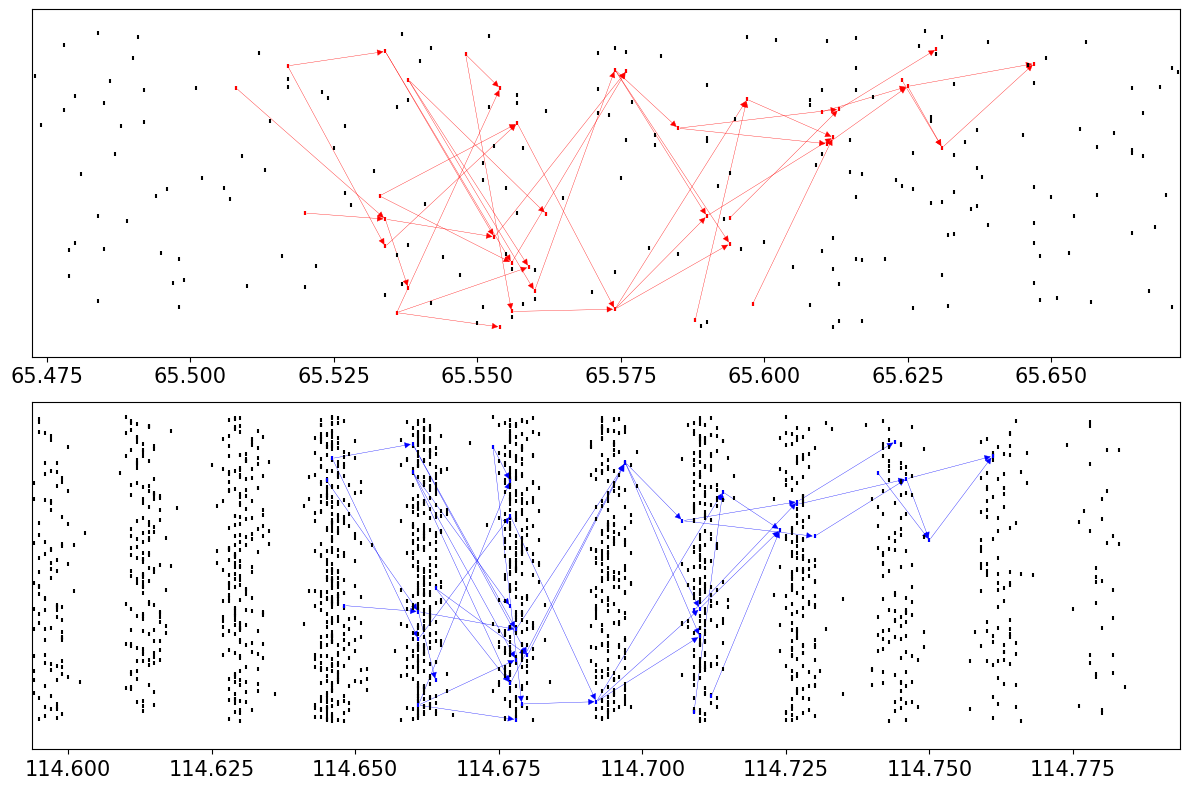

In [19]:


# Plot the isomorphic causal subgraphs
fig, axs = plt.subplots(2, 1, figsize=(12, 8), tight_layout=True)
wd = 0.1
lg = [cq1_g1, cq1_g2]
print(len(lg[0].nodes()))
print(len(lg[1].nodes()))

# convert spike times to positions
pos1 = get_pos(lg[0])
pos2 = get_pos(lg[1])

x1_center = get_center(pos1)
x2_center = get_center(pos2)

# Draw 1
color = 'r'
nx.draw_networkx(lg[0], pos1, node_size=8, ax=axs[0], with_labels=False, arrows=True,
             alpha=1, node_color=color, 
                width=0.25, edge_vmin=0, edge_vmax=0.75, node_shape="|",
                edge_color=color)

axs[0].tick_params(left=True, bottom=True, labelleft=True, labelbottom=True, labelsize=15)
axs[0].set_xlim(x1_center-wd, x1_center+wd)
axs[0].scatter(all_spikes_times/1000, all_spikes_cells/10, marker='|', s=8, c='k')
axs[0].set_yticks([])

# Draw 2
color = 'b'
nx.draw_networkx(lg[1], pos2, node_size=8, ax=axs[1], with_labels=False, arrows=True,
             alpha=1, node_color=color, 
                width=0.25, edge_vmin=0, edge_vmax=0.75, node_shape="|",
                edge_color=color)

axs[1].tick_params(left=True, bottom=True, labelleft=True, labelbottom=True, labelsize=15)
axs[1].set_xlim(x2_center-wd, x2_center+wd)
axs[1].scatter(all_spikes_times/1000, all_spikes_cells/10, marker='|', s=8, c='k')
axs[1].set_yticks([])
